# Complex Office Floorplan to Graph Visualization

This notebook demonstrates:
1. Creating a realistic office floorplan with 18 rooms
2. Combining them into a CellComplex
3. Creating a dual graph (rooms as vertices, shared walls as edges)
4. Visualizing both the geometry and the graph
5. Analyzing connectivity and pathfinding

In [1]:
import topologic_fast as tf
import plotly.graph_objects as go

## 1. Create a Complex Office Floorplan

We'll create a realistic office with:
- Reception & Lobby
- Open workspace areas
- Private offices
- Conference rooms
- Kitchen & Break room
- Server room & Storage
- Restrooms
- Corridors

```
+-----+-----+-----+-----+-----+-----+
|     |     |     |     |     |     |
|ConfA|Off1 |Off2 |Off3 |Off4 |ConfB|
|     |     |     |     |     |     |
+-----+-----+-----+-----+-----+-----+
|                                   |
|          North Corridor           |
|                                   |
+-----+-----+-----+-----+-----+-----+
|     |     |     |     |     |     |
|Kitch|Break|Servr|Strge|WC-M |WC-F |
|     |     |     |     |     |     |
+------+----+-----+-----+-----+-----+
|      |                            |
| W.S. |      South Corridor        |
| West |                            |
+------+---------------+------------+
|                      |            |
|   Workspace East     |Open Meeting|
|                      |            |
+----+-----------------+------------+
|    |                              |
|Rcpt|          Lobby               |
|    |                              |
+----+------------------------------+
```

In [2]:
# Building parameters
floor_height = 3.0  # meters
building_width = 30.0  # meters

rooms = []
room_names = []
room_colors = []
room_types = []

# Color scheme by room type
color_map = {
    'lobby': '#87CEEB',      # Sky blue
    'reception': '#4682B4',   # Steel blue
    'corridor': '#D3D3D3',    # Light gray
    'office': '#90EE90',      # Light green
    'conference': '#FFD700',  # Gold
    'workspace': '#98FB98',   # Pale green
    'kitchen': '#FFDAB9',     # Peach
    'break': '#FFE4B5',       # Moccasin
    'server': '#B0C4DE',      # Light steel blue
    'storage': '#C0C0C0',     # Silver
    'restroom': '#E6E6FA',    # Lavender
    'meeting': '#F0E68C'      # Khaki
}

def add_room(x, y, w, l, name, rtype):
    """Helper to add a room"""
    room = tf.Cell.Box(x, y, 0, w, l, floor_height)
    rooms.append(room)
    room_names.append(name)
    room_colors.append(color_map[rtype])
    room_types.append(rtype)
    return room

# ============ ROW 1: Lobby and Reception (y = 0 to 4) ============
add_room(0, 0, 4, 4, 'Reception', 'reception')
add_room(4, 0, 26, 4, 'Lobby', 'lobby')

# ============ ROW 2: Workspace East & Open Meeting (y = 4 to 8) ============
add_room(0, 4, 15, 4, 'Workspace East', 'workspace')
add_room(15, 4, 15, 4, 'Open Meeting Area', 'meeting')

# ============ ROW 3: Workspace West & South Corridor (y = 8 to 12) ============
add_room(0, 8, 6, 4, 'Workspace West', 'workspace')
add_room(6, 8, 24, 4, 'South Corridor', 'corridor')

# ============ ROW 4: Service Rooms (y = 12 to 16) ============
add_room(0, 12, 5, 4, 'Kitchen', 'kitchen')
add_room(5, 12, 5, 4, 'Break Room', 'break')
add_room(10, 12, 5, 4, 'Server Room', 'server')
add_room(15, 12, 5, 4, 'Storage', 'storage')
add_room(20, 12, 5, 4, 'WC (Men)', 'restroom')
add_room(25, 12, 5, 4, 'WC (Women)', 'restroom')

# ============ ROW 5: North Corridor (y = 16 to 20) ============
add_room(0, 16, 30, 4, 'North Corridor', 'corridor')

# ============ ROW 6: Offices and Conference Rooms (y = 20 to 26) ============
add_room(0, 20, 5, 6, 'Conference Room A', 'conference')
add_room(5, 20, 5, 6, 'Office 1', 'office')
add_room(10, 20, 5, 6, 'Office 2', 'office')
add_room(15, 20, 5, 6, 'Office 3', 'office')
add_room(20, 20, 5, 6, 'Office 4', 'office')
add_room(25, 20, 5, 6, 'Conference Room B', 'conference')

# Print summary
print(f"Created {len(rooms)} rooms:\n")
total_area = 0
for i, (room, name, rtype) in enumerate(zip(rooms, room_names, room_types)):
    area = room.Volume() / floor_height
    total_area += area
    print(f"  {i+1:2d}. {name:22s} [{rtype:10s}] - {area:6.1f} m²")

print(f"\n{'='*55}")
print(f"Total floor area: {total_area:.1f} m² ({total_area * 10.764:.0f} sq ft)")

Created 19 rooms:

   1. Reception              [reception ] -   16.0 m²
   2. Lobby                  [lobby     ] -  104.0 m²
   3. Workspace East         [workspace ] -   60.0 m²
   4. Open Meeting Area      [meeting   ] -   60.0 m²
   5. Workspace West         [workspace ] -   24.0 m²
   6. South Corridor         [corridor  ] -   96.0 m²
   7. Kitchen                [kitchen   ] -   20.0 m²
   8. Break Room             [break     ] -   20.0 m²
   9. Server Room            [server    ] -   20.0 m²
  10. Storage                [storage   ] -   20.0 m²
  11. WC (Men)               [restroom  ] -   20.0 m²
  12. WC (Women)             [restroom  ] -   20.0 m²
  13. North Corridor         [corridor  ] -  120.0 m²
  14. Conference Room A      [conference] -   30.0 m²
  15. Office 1               [office    ] -   30.0 m²
  16. Office 2               [office    ] -   30.0 m²
  17. Office 3               [office    ] -   30.0 m²
  18. Office 4               [office    ] -   30.0 m²
  19. Con

## 2. Create CellComplex

In [3]:
# Combine all rooms into a CellComplex
floorplan = tf.CellComplex.ByCells(rooms)

print(f"CellComplex Statistics:")
print(f"  Cells (rooms):     {floorplan.NumCells()}")
print(f"  Total Volume:      {floorplan.Volume():.1f} m³")
print(f"  Total Surface:     {floorplan.Area():.1f} m²")

CellComplex Statistics:
  Cells (rooms):     19
  Total Volume:      2340.0 m³
  Total Surface:     3168.0 m²


## 3. Create Dual Graph

The dual graph represents room connectivity:
- **Vertices** = Room centroids
- **Edges** = Shared walls between rooms

In [4]:
# Create the dual graph
graph = tf.Graph.ByTopology(floorplan)

print(f"Connectivity Graph:")
print(f"  Vertices (rooms):      {graph.Order()}")
print(f"  Edges (connections):   {graph.Size()}")
print(f"\nGraph Metrics:")
print(f"  Density:               {graph.Density():.3f}")
print(f"  Diameter:              {graph.Diameter()} steps (max distance)")
print(f"  Max connections:       {graph.MaximumDelta()} (most connected room)")
print(f"  Min connections:       {graph.MinimumDelta()} (least connected room)")
print(f"  Is Bipartite:          {graph.IsBipartite()}")

Connectivity Graph:
  Vertices (rooms):      19
  Edges (connections):   38

Graph Metrics:
  Density:               0.222
  Diameter:              5 steps (max distance)
  Max connections:       12 (most connected room)
  Min connections:       2 (least connected room)
  Is Bipartite:          False


## 4. Room Connectivity Analysis

In [5]:
# Get graph vertices
graph_vertices = graph.Vertices()

def get_room_index(vertex):
    """Find room index for a graph vertex"""
    coords = vertex.Coordinates()
    for i, gv in enumerate(graph_vertices):
        gc = gv.Coordinates()
        if abs(coords[0] - gc[0]) < 0.1 and abs(coords[1] - gc[1]) < 0.1:
            return i
    return -1

# Analyze connectivity
connectivity = []
for i, vertex in enumerate(graph_vertices):
    adjacent = graph.AdjacentVertices(vertex)
    neighbor_names = [room_names[get_room_index(v)] for v in adjacent]
    connectivity.append((room_names[i], room_types[i], len(neighbor_names), neighbor_names))

# Sort by number of connections (descending)
connectivity.sort(key=lambda x: -x[2])

print("Room Connectivity (sorted by # of connections):")
print("=" * 70)
for name, rtype, count, neighbors in connectivity:
    print(f"\n{name} [{rtype}] - {count} connection(s):")
    for n in sorted(neighbors):
        print(f"    → {n}")

Room Connectivity (sorted by # of connections):

North Corridor [corridor] - 12 connection(s):
    → Break Room
    → Conference Room A
    → Conference Room B
    → Kitchen
    → Office 1
    → Office 2
    → Office 3
    → Office 4
    → Server Room
    → Storage
    → WC (Men)
    → WC (Women)

South Corridor [corridor] - 8 connection(s):
    → Break Room
    → Open Meeting Area
    → Server Room
    → Storage
    → WC (Men)
    → WC (Women)
    → Workspace East
    → Workspace West

Workspace East [workspace] - 5 connection(s):
    → Lobby
    → Open Meeting Area
    → Reception
    → South Corridor
    → Workspace West

Break Room [break] - 5 connection(s):
    → Kitchen
    → North Corridor
    → Server Room
    → South Corridor
    → Workspace West

Workspace West [workspace] - 4 connection(s):
    → Break Room
    → Kitchen
    → South Corridor
    → Workspace East

Server Room [server] - 4 connection(s):
    → Break Room
    → North Corridor
    → South Corridor
    → Storage


## 5. 2D Floor Plan Visualization

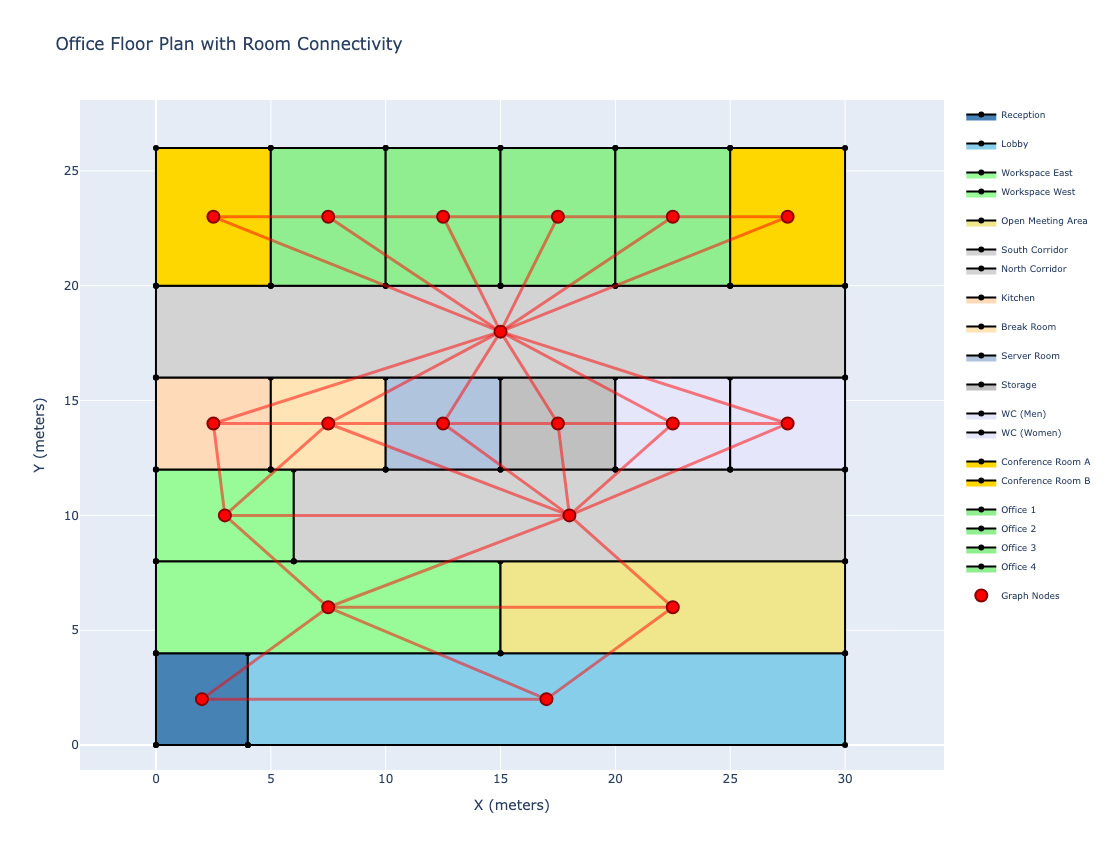

In [6]:
def visualize_2d_floorplan(cellcomplex, graph, room_names, room_colors, show_graph=True):
    """Create a 2D top-down view of the floorplan"""
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    
    # Draw rooms
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        for face in faces:
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            z_coords = [c[2] for c in coords]
            # Find bottom face (z ≈ 0)
            if all(abs(z) < 0.01 for z in z_coords):
                x = [c[0] for c in coords] + [coords[0][0]]
                y = [c[1] for c in coords] + [coords[0][1]]
                
                fig.add_trace(go.Scatter(
                    x=x, y=y,
                    fill='toself',
                    fillcolor=room_colors[i],
                    line=dict(color='black', width=2),
                    name=room_names[i],
                    hoverinfo='name',
                    legendgroup=room_types[i],
                    showlegend=True
                ))
                break
    
    if show_graph:
        # Draw graph edges
        graph_edges = graph.Edges()
        for edge in graph_edges:
            edge_verts = edge.Vertices()
            if len(edge_verts) == 2:
                p1 = edge_verts[0].Coordinates()
                p2 = edge_verts[1].Coordinates()
                fig.add_trace(go.Scatter(
                    x=[p1[0], p2[0]],
                    y=[p1[1], p2[1]],
                    mode='lines',
                    line=dict(color='rgba(255,0,0,0.5)', width=3),
                    showlegend=False,
                    hoverinfo='skip'
                ))
        
        # Draw graph vertices
        graph_vertices = graph.Vertices()
        vertex_coords = [v.Coordinates() for v in graph_vertices]
        x = [c[0] for c in vertex_coords]
        y = [c[1] for c in vertex_coords]
        
        fig.add_trace(go.Scatter(
            x=x, y=y,
            mode='markers',
            marker=dict(size=12, color='red', line=dict(color='darkred', width=2)),
            name='Graph Nodes',
            hovertext=room_names,
            hoverinfo='text'
        ))
    
    fig.update_layout(
        title='Office Floor Plan with Room Connectivity',
        xaxis=dict(title='X (meters)', scaleanchor='y', scaleratio=1, range=[-1, 32]),
        yaxis=dict(title='Y (meters)', range=[-1, 28]),
        width=1000,
        height=850,
        showlegend=True,
        legend=dict(x=1.02, y=1, font=dict(size=9))
    )
    
    return fig

fig_2d = visualize_2d_floorplan(floorplan, graph, room_names, room_colors)
fig_2d.show()

## 6. 3D Visualization

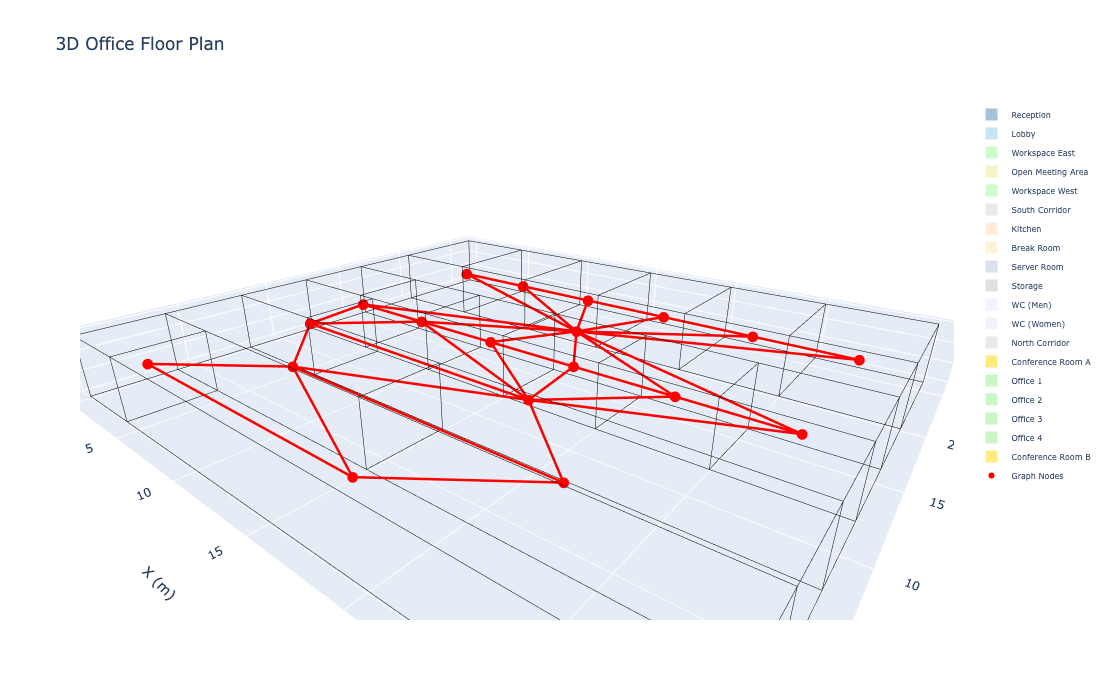

In [7]:
def visualize_3d(cellcomplex, graph, room_names, room_colors):
    """Create a 3D visualization"""
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    
    # Draw rooms
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        color = room_colors[i]
        
        for j, face in enumerate(faces):
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            
            if len(coords) >= 3:
                x = [c[0] for c in coords]
                y = [c[1] for c in coords]
                z = [c[2] for c in coords]
                
                fig.add_trace(go.Mesh3d(
                    x=x, y=y, z=z,
                    color=color,
                    opacity=0.5,
                    alphahull=0,
                    name=room_names[i],
                    showlegend=(j == 0)
                ))
                
                # Add edges
                for k in range(len(coords)):
                    p1 = coords[k]
                    p2 = coords[(k + 1) % len(coords)]
                    fig.add_trace(go.Scatter3d(
                        x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
                        mode='lines',
                        line=dict(color='black', width=1),
                        showlegend=False,
                        hoverinfo='skip'
                    ))
    
    # Draw graph edges
    graph_edges = graph.Edges()
    for edge in graph_edges:
        edge_verts = edge.Vertices()
        if len(edge_verts) == 2:
            p1 = edge_verts[0].Coordinates()
            p2 = edge_verts[1].Coordinates()
            fig.add_trace(go.Scatter3d(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],
                mode='lines',
                line=dict(color='red', width=5),
                showlegend=False,
                hoverinfo='skip'
            ))
    
    # Draw graph vertices
    graph_vertices = graph.Vertices()
    vertex_coords = [v.Coordinates() for v in graph_vertices]
    x = [c[0] for c in vertex_coords]
    y = [c[1] for c in vertex_coords]
    z = [c[2] for c in vertex_coords]
    
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=6, color='red'),
        name='Graph Nodes',
        hovertext=room_names,
        hoverinfo='text'
    ))
    
    fig.update_layout(
        title='3D Office Floor Plan',
        scene=dict(
            aspectmode='data',
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)',
            camera=dict(eye=dict(x=1.2, y=-1.5, z=0.8))
        ),
        width=1000,
        height=700,
        legend=dict(x=1.02, y=1, font=dict(size=8))
    )
    
    return fig

fig_3d = visualize_3d(floorplan, graph, room_names, room_colors)
fig_3d.show()

## 7. Pathfinding

In [8]:
def find_path(start_name, end_name):
    """Find shortest path between two rooms"""
    start_idx = room_names.index(start_name)
    end_idx = room_names.index(end_name)
    
    start_v = graph_vertices[start_idx]
    end_v = graph_vertices[end_idx]
    
    distance = graph.Distance(start_v, end_v)
    path = graph.Path(start_v, end_v)
    
    if path:
        path_vertices = path.Vertices()
        path_names = [room_names[get_room_index(v)] for v in path_vertices]
        return distance, path_names
    return None, []

# Test various paths
test_paths = [
    ('Reception', 'Conference Room B'),
    ('Lobby', 'Office 3'),
    ('Kitchen', 'Conference Room A'),
    ('WC (Men)', 'Workspace East'),
    ('Server Room', 'Office 4'),
    ('Workspace West', 'Open Meeting Area'),
]

print("Shortest Paths Between Rooms")
print("=" * 70)

for start, end in test_paths:
    dist, path = find_path(start, end)
    print(f"\n{start} → {end}:")
    print(f"  Distance: {dist} room(s)")
    print(f"  Route: {' → '.join(path)}")

Shortest Paths Between Rooms

Reception → Conference Room B:
  Distance: 5 room(s)
  Route: Reception → Workspace East → Workspace West → Kitchen → North Corridor → Conference Room B

Lobby → Office 3:
  Distance: 5 room(s)
  Route: Lobby → Workspace East → Workspace West → Kitchen → North Corridor → Office 3

Kitchen → Conference Room A:
  Distance: 2 room(s)
  Route: Kitchen → North Corridor → Conference Room A

WC (Men) → Workspace East:
  Distance: 2 room(s)
  Route: WC (Men) → South Corridor → Workspace East

Server Room → Office 4:
  Distance: 2 room(s)
  Route: Server Room → North Corridor → Office 4

Workspace West → Open Meeting Area:
  Distance: 2 room(s)
  Route: Workspace West → Workspace East → Open Meeting Area


## 8. Visualize a Path

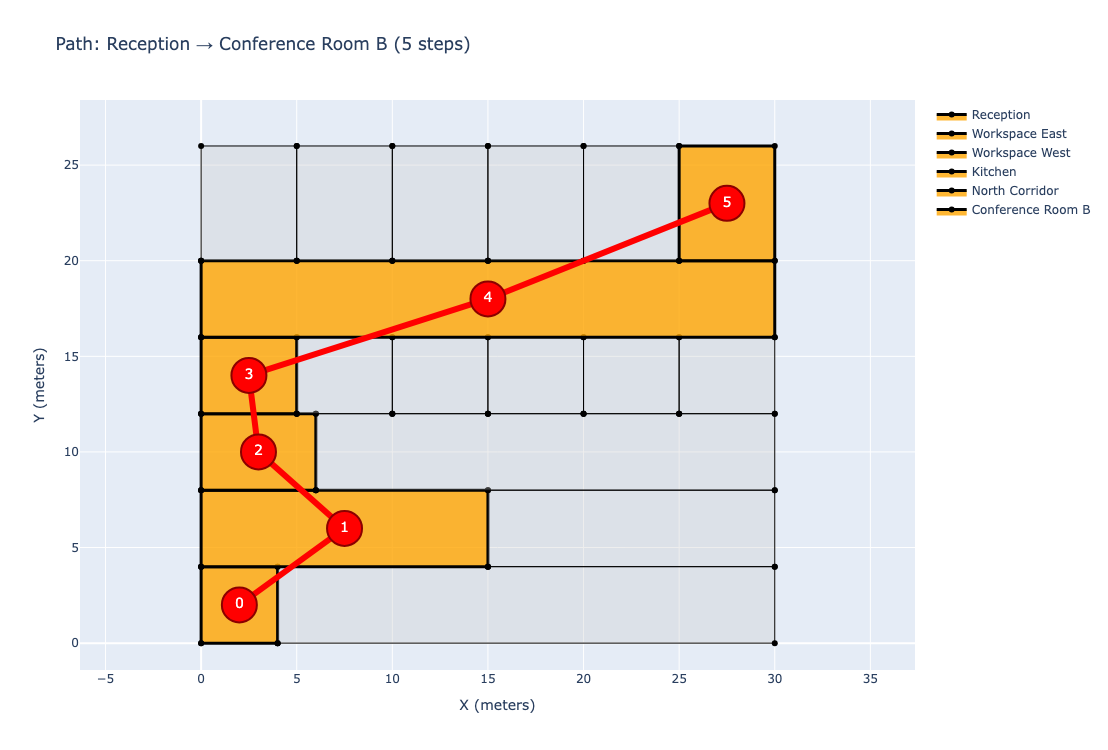

In [9]:
def visualize_path(start_name, end_name):
    """Visualize a specific path"""
    fig = go.Figure()
    
    cells = floorplan.Cells()
    dist, path = find_path(start_name, end_name)
    path_set = set(path)
    
    # Draw all rooms
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        for face in faces:
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            z_coords = [c[2] for c in coords]
            if all(abs(z) < 0.01 for z in z_coords):
                x = [c[0] for c in coords] + [coords[0][0]]
                y = [c[1] for c in coords] + [coords[0][1]]
                
                if room_names[i] in path_set:
                    color = 'rgba(255, 165, 0, 0.8)'  # Orange
                    width = 3
                else:
                    color = 'rgba(200, 200, 200, 0.3)'
                    width = 1
                
                fig.add_trace(go.Scatter(
                    x=x, y=y,
                    fill='toself',
                    fillcolor=color,
                    line=dict(color='black', width=width),
                    name=room_names[i],
                    hoverinfo='name',
                    showlegend=room_names[i] in path_set
                ))
                break
    
    # Draw path edges
    for i in range(len(path) - 1):
        idx1 = room_names.index(path[i])
        idx2 = room_names.index(path[i + 1])
        p1 = graph_vertices[idx1].Coordinates()
        p2 = graph_vertices[idx2].Coordinates()
        
        fig.add_trace(go.Scatter(
            x=[p1[0], p2[0]],
            y=[p1[1], p2[1]],
            mode='lines',
            line=dict(color='red', width=6),
            showlegend=False
        ))
    
    # Draw path vertices with step numbers
    path_coords = [graph_vertices[room_names.index(name)].Coordinates() for name in path]
    x = [c[0] for c in path_coords]
    y = [c[1] for c in path_coords]
    
    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='markers+text',
        marker=dict(size=35, color='red', line=dict(color='darkred', width=2)),
        text=[str(i) for i in range(len(path))],
        textposition='middle center',
        textfont=dict(size=14, color='white'),
        hovertext=path,
        hoverinfo='text',
        showlegend=False
    ))
    
    fig.update_layout(
        title=f'Path: {start_name} → {end_name} ({dist} steps)',
        xaxis=dict(title='X (meters)', scaleanchor='y', scaleratio=1, range=[-1, 32]),
        yaxis=dict(title='Y (meters)', range=[-1, 28]),
        width=900,
        height=750
    )
    
    return fig

# Visualize path from Reception to Conference Room B
fig_path = visualize_path('Reception', 'Conference Room B')
fig_path.show()

## 9. Distance Matrix Heatmap

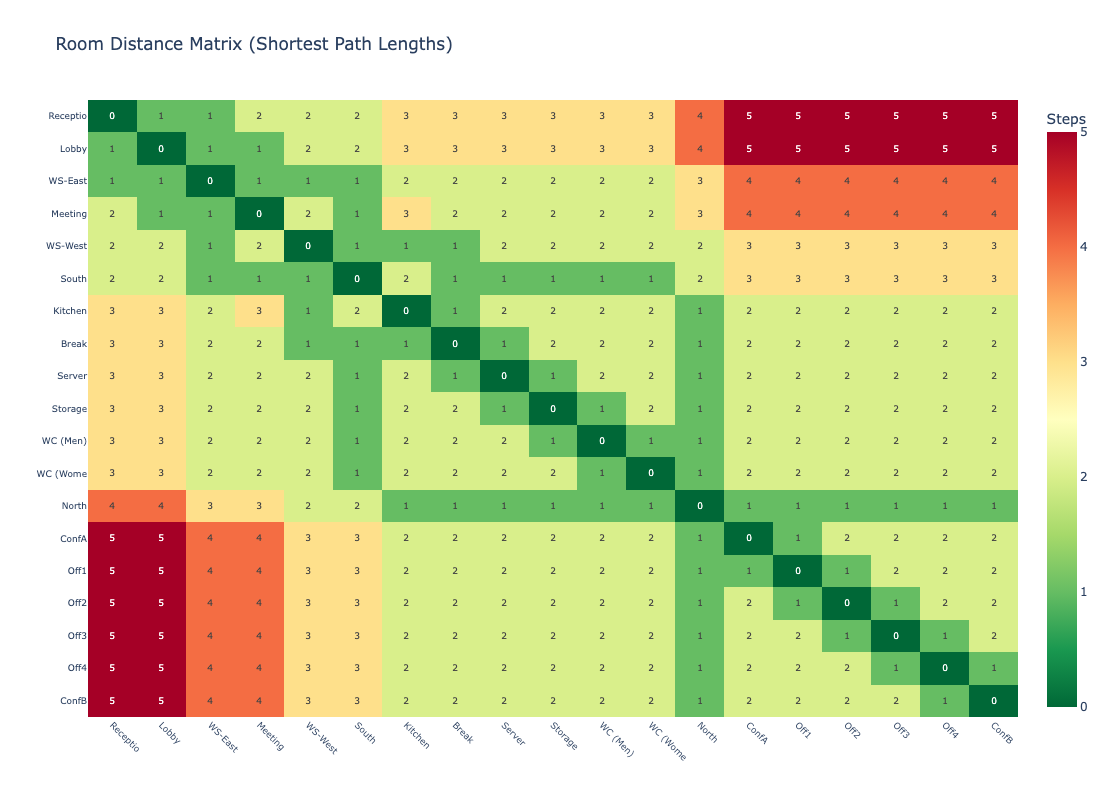

In [10]:
# Calculate distance matrix
n = len(room_names)
distance_matrix = []

for i in range(n):
    row = []
    for j in range(n):
        if i == j:
            row.append(0)
        else:
            dist = graph.Distance(graph_vertices[i], graph_vertices[j])
            row.append(dist if dist else -1)
    distance_matrix.append(row)

# Create short labels
short_names = []
for name in room_names:
    if 'Office' in name:
        short_names.append(name.replace('Office ', 'Off'))
    elif 'Conference' in name:
        short_names.append(name.replace('Conference Room ', 'Conf'))
    elif 'Workspace' in name:
        short_names.append(name.replace('Workspace ', 'WS-'))
    elif 'Corridor' in name:
        short_names.append(name.replace(' Corridor', ''))
    elif name == 'Open Meeting Area':
        short_names.append('Meeting')
    elif name == 'Break Room':
        short_names.append('Break')
    elif name == 'Server Room':
        short_names.append('Server')
    else:
        short_names.append(name[:8])

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=distance_matrix,
    x=short_names,
    y=short_names,
    colorscale='RdYlGn_r',
    text=distance_matrix,
    texttemplate='%{text}',
    textfont=dict(size=9),
    colorbar=dict(title='Steps')
))

fig.update_layout(
    title='Room Distance Matrix (Shortest Path Lengths)',
    xaxis=dict(title='', tickangle=45, tickfont=dict(size=9)),
    yaxis=dict(title='', autorange='reversed', tickfont=dict(size=9)),
    width=900,
    height=800
)

fig.show()

## 10. Room Type Statistics

Room Type Statistics:
Type             Count    Area (m²)    Avg Connections
----------------------------------------------------------------------
corridor             2        216.0               10.0
office               4        120.0                3.0
lobby                1        104.0                3.0
workspace            2         84.0                4.5
meeting              1         60.0                3.0
conference           2         60.0                2.0
restroom             2         40.0                3.5
kitchen              1         20.0                3.0
break                1         20.0                5.0
server               1         20.0                4.0
storage              1         20.0                4.0
reception            1         16.0                2.0


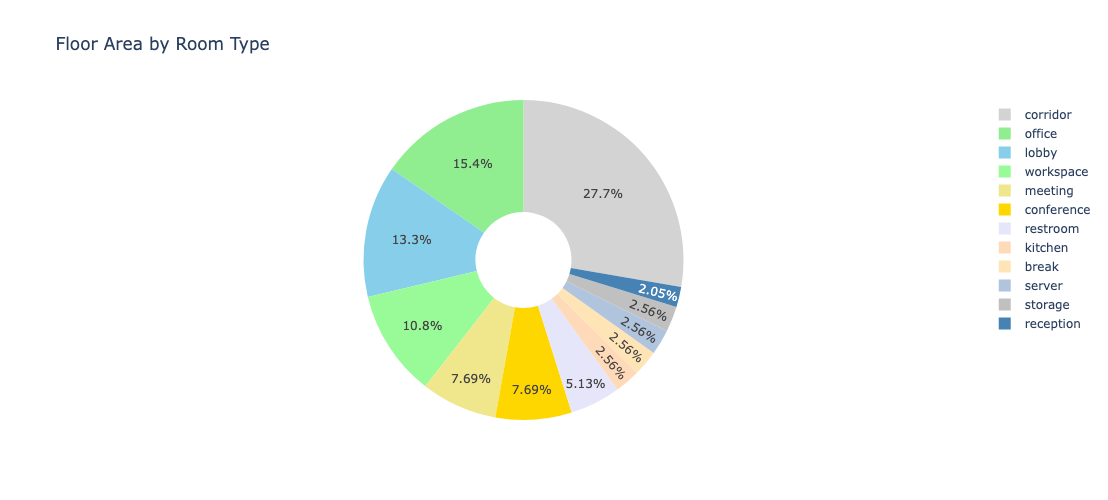

In [11]:
# Aggregate by room type
type_stats = {}
for i, (room, rtype) in enumerate(zip(rooms, room_types)):
    area = room.Volume() / floor_height
    if rtype not in type_stats:
        type_stats[rtype] = {'count': 0, 'area': 0, 'connections': 0}
    type_stats[rtype]['count'] += 1
    type_stats[rtype]['area'] += area
    type_stats[rtype]['connections'] += graph.VertexDegree(graph_vertices[i])

print("Room Type Statistics:")
print("=" * 70)
print(f"{'Type':<15} {'Count':>6} {'Area (m²)':>12} {'Avg Connections':>18}")
print("-" * 70)

for rtype, stats in sorted(type_stats.items(), key=lambda x: -x[1]['area']):
    avg_conn = stats['connections'] / stats['count']
    print(f"{rtype:<15} {stats['count']:>6} {stats['area']:>12.1f} {avg_conn:>18.1f}")

# Pie chart
fig = go.Figure(data=[go.Pie(
    labels=list(type_stats.keys()),
    values=[s['area'] for s in type_stats.values()],
    hole=.3,
    marker_colors=[color_map[t] for t in type_stats.keys()]
)])

fig.update_layout(
    title='Floor Area by Room Type',
    width=600,
    height=500
)

fig.show()

## Summary

This notebook demonstrated:

1. **Complex Floorplan Creation** - 18 rooms of various sizes and functions
2. **CellComplex Construction** - Topological representation of the building
3. **Dual Graph Generation** - Room connectivity graph via `Graph.ByTopology()`
4. **Connectivity Analysis** - Which rooms connect to which
5. **Pathfinding** - Shortest routes between any two rooms
6. **Visualization** - 2D plans, 3D views, and heatmaps

### Key Findings:
- **Corridors** are the most connected spaces (hub nodes)
- **Maximum distance** between any rooms: check the diameter
- **Graph density** indicates how interconnected the layout is

### Applications:
- Building Information Modeling (BIM)
- Space syntax & wayfinding analysis
- Emergency egress planning
- HVAC zoning optimization
- Security access control design